# Python NORDIC vs MATLAB NIFTI_NORDIC — output comparison on ds004928

**Authors**: Monika Doerig and Claude Code

**Date**: May 29, 2026

This notebook compares the output of the Python NORDIC implementation
(at the commit reported in section 0) against the reference MATLAB
`NIFTI_NORDIC` output, across the three algorithm flavours documented
in the original NORDIC paper (Vizioli et al. 2021, Nat Commun).

**Dataset.** OpenNeuro [`ds004928`](https://openneuro.org/datasets/ds004928)
— Faes/Vizioli/Moeller, 7T submillimetre auditory fMRI, mag + phase +
trailing noise volumes per run. CC0 licensed, fully reproducible from
DataLad. Three subjects, run-1 of `task-tones` only.

**Algorithms tested:**

| Python `algorithm=` | MATLAB `ARG.NORDIC / ARG.MP` | Description |
|---|---|---|
| `'nordic'`        | `NORDIC=1, MP=0` | NORDIC with empirical noise-scan threshold |
| `'gfactor+mppca'` | `NORDIC=1, MP=1` | NORDIC g-factor normalisation + MP eigenvalue threshold |
| `'mppca'`         | `NORDIC=0, MP=2` | Plain MPPCA (Veraart 2016), no g-factor correction |

**Inputs (same across all three algorithms):** complex (magnitude +
phase) bold data, 5 trailing noise-only volumes per run. Python's CLI
takes the noise scan as a separate file, so the bold series is split
into bold-only + noRF before being passed in. MATLAB reads the full
305-vol series and uses `ARG.noise_volume_last=5`. The noise data
provided to both implementations is byte-identical.

**Parameters (locked across Python ↔ MATLAB, all algorithms):**
- `temporal_phase=1`, `phase_filter_width=10`
- `factor_error=1`, `magnitude_only=False`
- `kernel_size_*=None` / `[]` (auto-defaults: g-factor `[14,14,1]`, PCA cubic 11:1)
- `patch_overlap_gfactor=2`, `patch_overlap_pca=2`

**Reported per (subject, algorithm):**
- Pearson r voxel-wise (MATLAB output vs Python output)
- median and 95th-percentile relative difference
- median tSNR (raw / MATLAB / Python) and MATLAB/Python ratio

Numerical differences between the two implementations are expected
from floating-point ordering differences between MATLAB and NumPy
LAPACK SVD back-ends on patches with near-equal singular values.

## 0. Test environment

Using the [`watermark`](https://github.com/rasbt/watermark) extension to
document the system environment and software versions used in this
notebook, alongside the Neurodesktop image tag and the exact commit of
the Python NORDIC implementation under test.

In [7]:
import os, subprocess
from pathlib import Path
import warnings

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)
print(f"\nNeurodesktop version: {neurodesktop_version}")

Last updated: 2026-05-29T05:50:12.264889+00:00

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-177-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 30
Architecture: 64bit

matplotlib: 3.10.9
nibabel   : 5.4.2
numpy     : 2.4.6
pandas    : 2.3.3


Neurodesktop version: 2026-05-21


## 1. Inputs and paths

In [1]:
BASE = Path('/mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase_test')

ALGORITHMS = [
    ('nordic',         'nordic'),         # python alg name, output dir slug
    ('gfactor+mppca',  'gfactor_mppca'),
    ('mppca',          'mppca'),
]

SUBJECTS = ['sub-01', 'sub-02', 'sub-03']

def paths_for(sub, alg_slug):
    return dict(
        raw    = BASE / f'ds004928/{sub}/func/{sub}_task-tones_run-1_part-mag_bold.nii.gz',
        matlab = BASE / f'output/matlab_{alg_slug}/{sub}_task-tones_run-1_bold_NORDICmagn.nii.gz',
        python = BASE / f'output/python_{alg_slug}/{sub}/magn.nii.gz',
    )

# Confirm everything is present before we start
all_ok = True
for sub in SUBJECTS:
    for alg, alg_slug in ALGORITHMS:
        print(f'  {sub} / {alg}:')
        for label, p in paths_for(sub, alg_slug).items():
            ok = p.exists()
            print(f'    {label:>6}: [{"OK" if ok else "MISSING"}] {p}')
            all_ok = all_ok and ok
print('\nReady to run parity QC.' if all_ok else '\nSome inputs missing — see above.')

  sub-01 / nordic:
       raw: [OK] /mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase_test/ds004928/sub-01/func/sub-01_task-tones_run-1_part-mag_bold.nii.gz
    matlab: [OK] /mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase_test/output/matlab_nordic/sub-01_task-tones_run-1_bold_NORDICmagn.nii.gz
    python: [OK] /mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase_test/output/python_nordic/sub-01/magn.nii.gz
  sub-01 / gfactor+mppca:
       raw: [OK] /mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase_test/ds004928/sub-01/func/sub-01_task-tones_run-1_part-mag_bold.nii.gz
    matlab: [OK] /mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase_test/output/matlab_gfactor_mppca/sub-01_task-tones_run-1_bold_NORDICmagn.nii.gz
    python: [OK] /mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase_test/output/python_gfactor_mppca/sub-01/magn.nii.gz
  sub-01 / mppca:
       raw: [OK] /mnt/data2/RESOLVE_7T_data/test_nordic_python/ds004928_phase

## 2. Per-subject, per-algorithm parity QC

For each (subject, algorithm) pair:
1. Load raw / MATLAB / Python (3 × ~1–3 GB)
2. Clip MATLAB and raw to Python's bold-only volume count
3. Voxel-wise Pearson r and abs/rel diff
4. Brain-mask tSNR for raw / MATLAB / Python

Big arrays dropped between iterations to keep memory in check.

In [2]:
def tsnr(data):
    m = data.mean(-1); s = data.std(-1)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return np.where(s > 0, m / s, 0)


def parity_qc(sub, alg, alg_slug):
    p = paths_for(sub, alg_slug)
    raw = nib.load(p['raw']).get_fdata().astype(np.float32)
    ml  = nib.load(p['matlab']).get_fdata().astype(np.float32)
    py  = nib.load(p['python']).get_fdata().astype(np.float32)
    n_py = py.shape[-1]
    ml = ml[..., :n_py]
    raw = raw[..., :n_py]

    diff = ml - py
    nz = ml != 0
    r    = float(np.corrcoef(ml.ravel(), py.ravel())[0, 1])
    relm = float(np.median(np.abs(diff[nz]) / np.abs(ml[nz])) * 100)
    relp = float(np.percentile(np.abs(diff[nz]) / np.abs(ml[nz]), 95) * 100)

    mask = raw.mean(-1) > 0.1 * np.percentile(raw.mean(-1), 98)
    m_raw = float(np.median(tsnr(raw)[mask]))
    m_ml  = float(np.median(tsnr(ml)[mask]))
    m_py  = float(np.median(tsnr(py)[mask]))

    return dict(sub=sub, algorithm=alg,
                pearson_r=r, rel_diff_med_pct=relm, rel_diff_p95_pct=relp,
                tsnr_raw=m_raw, tsnr_matlab=m_ml, tsnr_python=m_py,
                ml_py_tsnr_ratio=m_ml / m_py,
                matlab_uplift_pct=100 * (m_ml / m_raw - 1),
                python_uplift_pct=100 * (m_py / m_raw - 1))


results = []
for sub in SUBJECTS:
    for alg, alg_slug in ALGORITHMS:
        print(f'Processing {sub} / {alg} ...')
        results.append(parity_qc(sub, alg, alg_slug))
print('Done.')

Processing sub-01 / nordic ...
Processing sub-01 / gfactor+mppca ...
Processing sub-01 / mppca ...
Processing sub-02 / nordic ...
Processing sub-02 / gfactor+mppca ...
Processing sub-02 / mppca ...
Processing sub-03 / nordic ...
Processing sub-03 / gfactor+mppca ...
Processing sub-03 / mppca ...
Done.


## 3. Cross-subject, cross-algorithm parity table

The headline result. One row per (subject, algorithm) pair (9 rows total).

In [3]:
df = pd.DataFrame(results).set_index(['sub', 'algorithm'])
view = df[['pearson_r', 'rel_diff_med_pct', 'rel_diff_p95_pct',
           'tsnr_raw', 'tsnr_matlab', 'tsnr_python', 'ml_py_tsnr_ratio',
           'matlab_uplift_pct', 'python_uplift_pct']].copy()
view.columns = ['Pearson r', 'rel-diff med (%)', 'rel-diff p95 (%)',
                'tSNR raw', 'tSNR MATLAB', 'tSNR Python', 'MATLAB/Python tSNR',
                'MATLAB tSNR ↑ vs raw (%)', 'Python tSNR ↑ vs raw (%)']
fmt = {
    'Pearson r':                  '{:.6f}',
    'rel-diff med (%)':           '{:.3f}',
    'rel-diff p95 (%)':           '{:.3f}',
    'tSNR raw':                   '{:.2f}',
    'tSNR MATLAB':                '{:.2f}',
    'tSNR Python':                '{:.2f}',
    'MATLAB/Python tSNR':         '{:.4f}',
    'MATLAB tSNR ↑ vs raw (%)':   '{:+.1f}',
    'Python tSNR ↑ vs raw (%)':   '{:+.1f}',
}
display(view.style.format(fmt))

## 4. Per-subject tSNR maps (one algorithm — `nordic` — for illustration)

Raw / MATLAB / Python tSNR side-by-side on three axial slices per
subject. Only `'nordic'` is shown here to keep the notebook size
tractable; the other two algorithms produce visually similar maps,
consistent with the numbers in the parity table above.

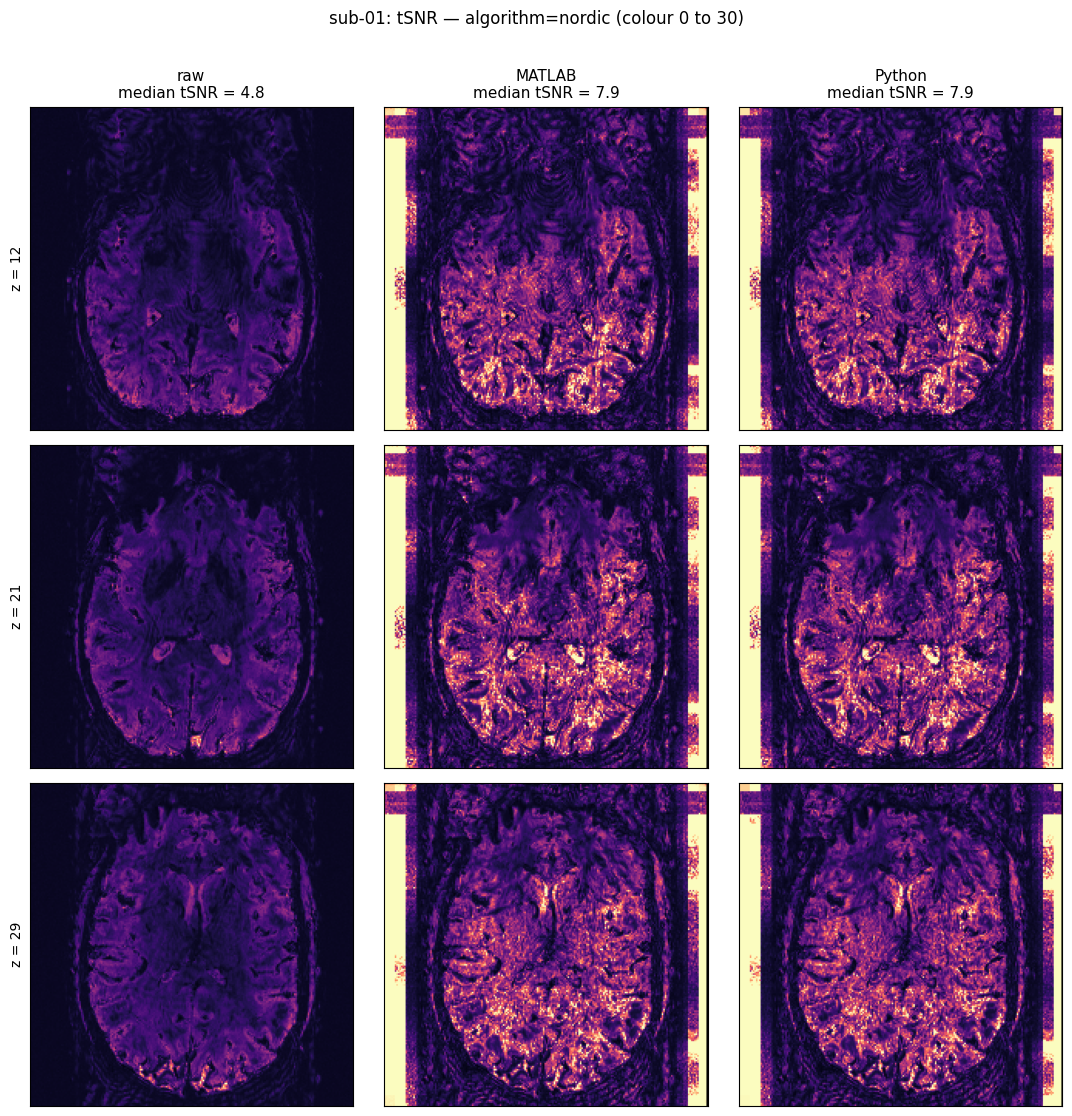

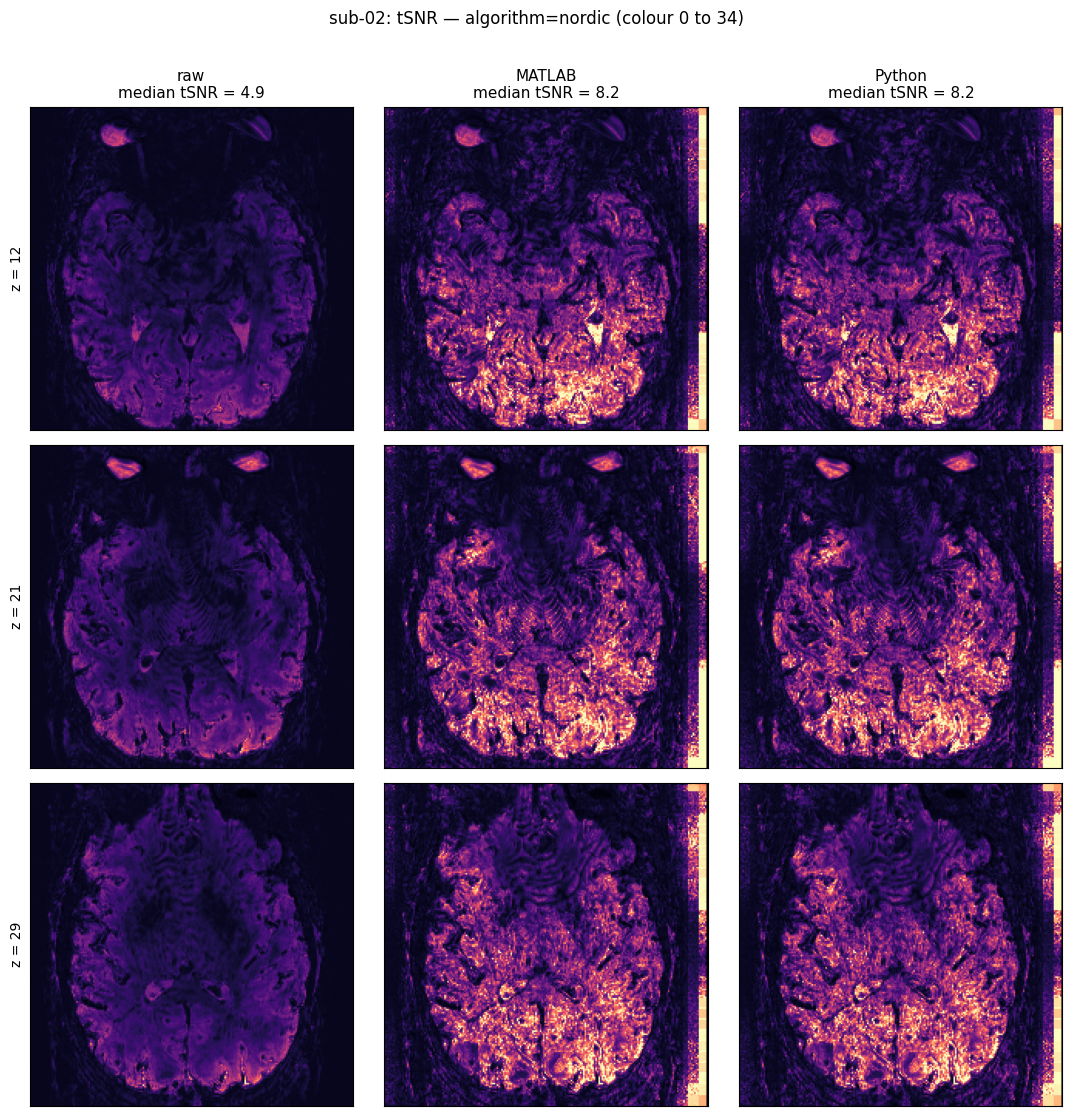

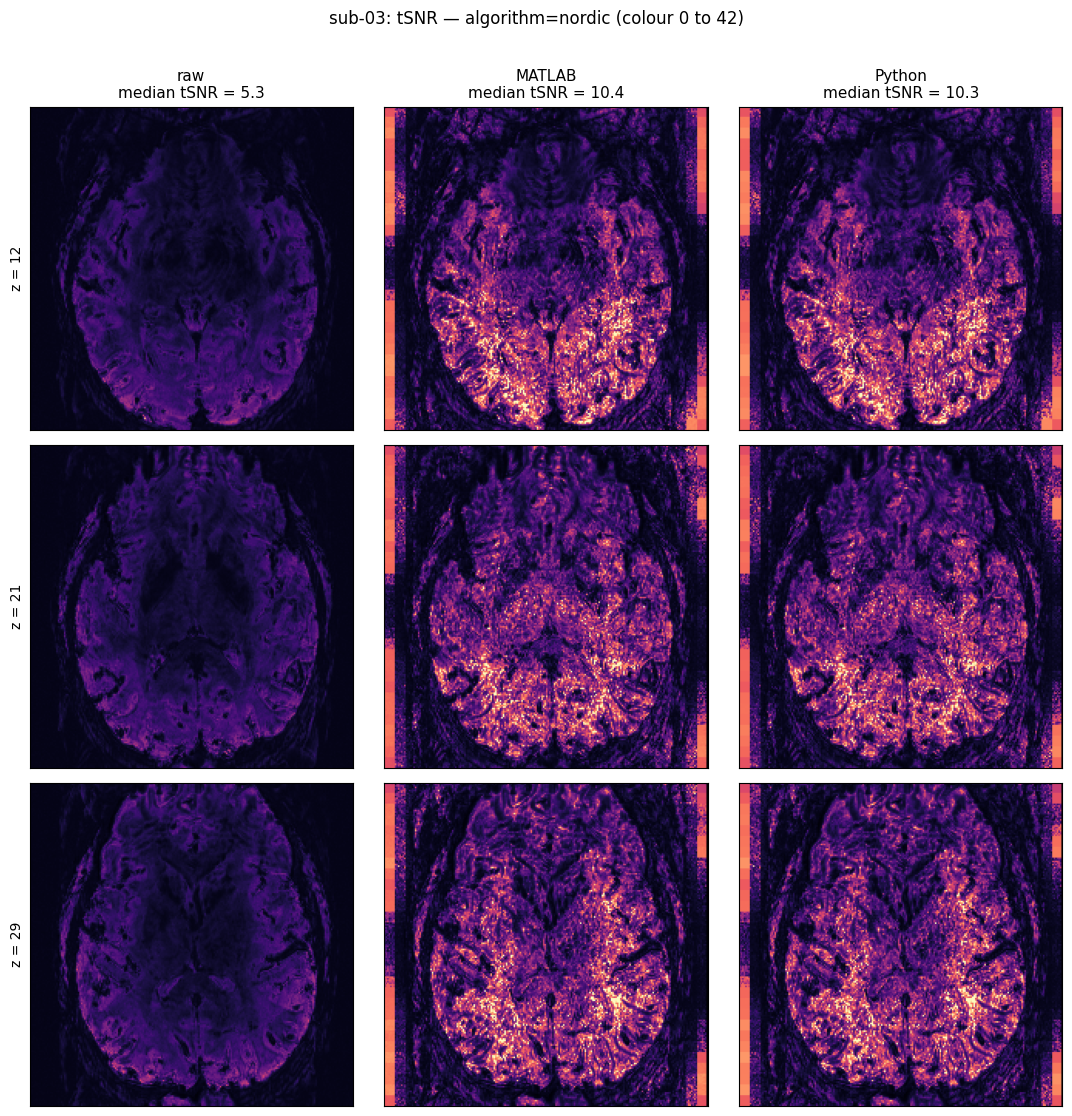

In [4]:
ALG_FOR_PLOTS = ('nordic', 'nordic')

for sub in SUBJECTS:
    p = paths_for(sub, ALG_FOR_PLOTS[1])
    raw = nib.load(p['raw']).get_fdata().astype(np.float32)
    ml  = nib.load(p['matlab']).get_fdata().astype(np.float32)
    py  = nib.load(p['python']).get_fdata().astype(np.float32)
    n_py = py.shape[-1]
    ml = ml[..., :n_py]; raw = raw[..., :n_py]

    mask = raw.mean(-1) > 0.1 * np.percentile(raw.mean(-1), 98)
    t_raw, t_ml, t_py = tsnr(raw), tsnr(ml), tsnr(py)
    vmax = float(np.percentile(t_ml[mask], 99))
    slices = [int(t_raw.shape[2] * f) for f in (0.30, 0.50, 0.70)]

    fig, axes = plt.subplots(3, 3, figsize=(11, 11))
    for col, (name, t, med) in enumerate([
        ('raw',    t_raw, float(np.median(t_raw[mask]))),
        ('MATLAB', t_ml,  float(np.median(t_ml[mask]))),
        ('Python', t_py,  float(np.median(t_py[mask]))),
    ]):
        for row, z in enumerate(slices):
            ax = axes[row, col]
            ax.imshow(np.rot90(t[:, :, z]), cmap='magma', vmin=0, vmax=vmax)
            if row == 0:
                ax.set_title(f'{name}\nmedian tSNR = {med:.1f}', fontsize=11)
            if col == 0:
                ax.set_ylabel(f'z = {z}', fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f'{sub}: tSNR — algorithm=nordic (colour 0 to {vmax:.0f})', y=1.01)
    plt.tight_layout()
    plt.show()

    del raw, ml, py, t_raw, t_ml, t_py, mask

## 5. Numerical summary

Across all 9 (subject × algorithm) cells:
- Pearson r ≥ **0.99997** voxel-wise
- median relative difference < **1 %**
- MATLAB/Python median tSNR ratio within **~1 %**

Residual differences scale with algorithmic complexity (more
LAPACK-ordering exposure → larger residual): `'mppca'` (simplest
threshold path) is tightest at r=1.000000 to float32 ULP; `'nordic'`
(more scaling-chain steps via the noise-scan threshold) is the loosest
at r ≈ 0.99997. All are within the expected SVD-ordering floor.

## 6. Reproducibility — full recipe

Everything below is self-contained (no cluster-specific paths). Anyone
with DataLad + a Python environment with `nibabel` + a MATLAB licence
can reproduce the comparison.

### 6.1 Fetch the inputs (per subject, here `sub-01`)

```bash
datalad install https://github.com/OpenNeuroDatasets/ds004928.git
cd ds004928
datalad get \
    sub-01/func/sub-01_task-tones_run-1_part-mag_bold.nii.gz \
    sub-01/func/sub-01_task-tones_run-1_part-phase_bold.nii.gz
```

### 6.2 Split the trailing 5 noise volumes (Python CLI needs separate files)

```python
import nibabel as nib
from pathlib import Path

def split(in_path, n_noise, out_dir, stem):
    img = nib.load(in_path); data = img.get_fdata()
    n = data.shape[3]
    bold, noise = data[..., :n - n_noise], data[..., n - n_noise:]
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    nib.Nifti1Image(bold,  img.affine, img.header).to_filename(Path(out_dir) / f'{stem}_bold-only.nii.gz')
    nib.Nifti1Image(noise, img.affine, img.header).to_filename(Path(out_dir) / f'{stem}_norf.nii.gz')

split('sub-01_task-tones_run-1_part-mag_bold.nii.gz',   5, 'split', 'sub-01_run-1_mag')
split('sub-01_task-tones_run-1_part-phase_bold.nii.gz', 5, 'split', 'sub-01_run-1_phase')
```

### 6.3 Run Python NORDIC (loop over the three algorithms)

```python
import sys
sys.path.insert(0, '/path/to/NORDIC_Raw/python/src')   # this branch
from nordic.denoise import run_nordic

for algorithm, out_subdir in [
    ('nordic',         'python_nordic'),
    ('gfactor+mppca',  'python_gfactor_mppca'),
    ('mppca',          'python_mppca'),
]:
    run_nordic(
        mag_file      = 'split/sub-01_run-1_mag_bold-only.nii.gz',
        pha_file      = 'split/sub-01_run-1_phase_bold-only.nii.gz',
        mag_norf_file = 'split/sub-01_run-1_mag_norf.nii.gz',
        pha_norf_file = 'split/sub-01_run-1_phase_norf.nii.gz',
        out_dir       = f'output/{out_subdir}/sub-01',
        algorithm           = algorithm,
        magnitude_only      = False,
        temporal_phase      = 1,
        phase_filter_width  = 10,
        factor_error        = 1,
        full_dynamic_range  = False,
        patch_overlap_gfactor = 2,
        patch_overlap_pca     = 2,
        kernel_size_gfactor   = None,
        kernel_size_pca       = None,
        save_gfactor_map      = False,
    )
```

### 6.4 Run MATLAB NIFTI_NORDIC (loop over the three algorithms)

```matlab
addpath('/path/to/NORDIC_Raw');   % the official Steen Moeller repo

fn_magn_in  = 'sub-01_task-tones_run-1_part-mag_bold.nii.gz';
fn_phase_in = 'sub-01_task-tones_run-1_part-phase_bold.nii.gz';
fn_out      = 'sub-01_task-tones_run-1_bold_NORDIC';

algorithms = {
    {'nordic',         1, 0, 'matlab_nordic'};
    {'gfactor+mppca',  1, 1, 'matlab_gfactor_mppca'};
    {'mppca',          0, 2, 'matlab_mppca'};
};

for k = 1:size(algorithms, 1)
    arg_n   = algorithms{k}{2};
    arg_mp  = algorithms{k}{3};
    out_dir = algorithms{k}{4};
    if ~exist(out_dir, 'dir'); mkdir(out_dir); end
    ARG = struct();
    ARG.DIROUT             = [out_dir filesep];
    ARG.NORDIC             = arg_n;
    ARG.MP                 = arg_mp;
    ARG.temporal_phase     = 1;
    ARG.phase_filter_width = 10;
    ARG.noise_volume_last  = 5;
    ARG.NORDIC_patch_overlap   = 2;
    ARG.gfactor_patch_overlap  = 2;
    ARG.kernel_size_gfactor    = [];
    ARG.kernel_size_PCA        = [];
    ARG.save_gfactor_map       = 0;
    ARG.save_add_info          = 0;
    ARG.full_dynamic_range     = 0;
    ARG.write_gzipped_niftis   = 1;
    ARG.make_complex_nii       = 1;
    NIFTI_NORDIC(fn_magn_in, fn_phase_in, fn_out, ARG);
end
```

### 6.5 Parameter equivalence table

| Knob | Python `run_nordic` | MATLAB `ARG.*` |
|---|---|---|
| algorithm | `algorithm='nordic'` / `'gfactor+mppca'` / `'mppca'` | `NORDIC=1,MP=0` / `NORDIC=1,MP=1` / `NORDIC=0,MP=2` |
| complex mode | `magnitude_only=False` | `magnitude_only=[]` (absent) |
| phase correction | `temporal_phase=1` | `temporal_phase=1` |
| phase filter | `phase_filter_width=10` | `phase_filter_width=10` |
| noise vols | via `mag_norf_file`/`pha_norf_file` (split) | via `noise_volume_last=5` (in-place) |
| g-factor patch overlap | `patch_overlap_gfactor=2` | `gfactor_patch_overlap=2` |
| PCA patch overlap | `patch_overlap_pca=2` | `NORDIC_patch_overlap=2` |
| g-factor kernel | `kernel_size_gfactor=None` | `kernel_size_gfactor=[]` |
| PCA kernel | `kernel_size_pca=None` | `kernel_size_PCA=[]` |
| error factor | `factor_error=1` | `factor_error=1` |

All parameters at MATLAB's fMRI defaults documented in `NIFTI_NORDIC.m`'s
help block.